# Грамматика и направление времени
### часть 2

в первой части доли тем стояли на месте (но можно думать что многообразия на которых лежат токены сообщений примерно стабильны).

Важный факт что доля тем это аггрегированная статистика, мы не смотрели на взаимодействия самих тем (запрещенные последовательности, ассимптотика количества разрешенных, и тд и тп)

ТЕ "что за чем идет" в теории может двигаться даже когда доли статичны

суммари: матрица переходов, всякие тесты грамматики, и про то, есть ли четкое направление времени

Импорты

In [1]:
#копипаст из предыдущего
import os
while not os.path.isdir("chats"): os.chdir("..")
import numpy as np, pandas as pd, seaborn as sns

df = pd.read_csv("chats/physics/df.csv", parse_dates=["ts"])
df = df[~df.is_bot].reset_index(drop=True)
cats = sorted(df.mega.unique())
K = len(cats)

## матрица переходов

берем пары i (вопрос) -> j (ответ/reply) и их темы соотвественно

In [ ]:
df.iloc[0]

In [ ]:
par = df.set_index("unit_id")["mega"]   
e = df[df["reply_to_unit"] >= 0].copy() #онли те которые на что-то отвечают

e["parent"] = e["reply_to_unit"].map(par) # q/a парсинг тем
e = e.dropna(subset=["parent"])
e.iloc[0]

<Axes: xlabel='mega', ylabel='parent'>

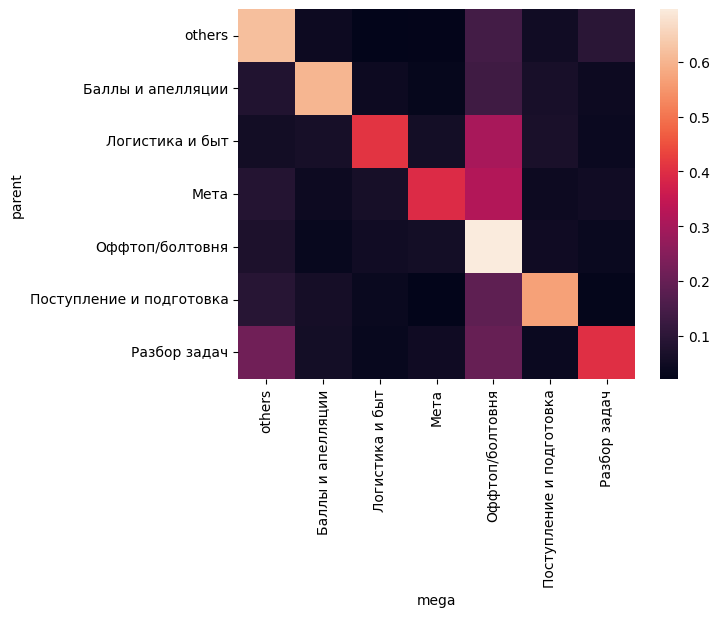

In [4]:
P = pd.crosstab(e["parent"], e["mega"], normalize="index")

sns.heatmap(P)

In [5]:
#диагональ яркая, на тему чаще отвечают той же темой
#но это может быть просто потому что тема частая, а не супер правило
#также заметно что все часто сливается в offtopic/болтовню!

In [6]:
tab = pd.crosstab(e["parent"], e["mega"])
tab

mega,others,Баллы и апелляции,Логистика и быт,Мета,Оффтоп/болтовня,Поступление и подготовка,Разбор задач
parent,,,,,,,
others,8310,606,293,349,1897,711,1294
Баллы и апелляции,627,4626,332,237,1028,505,333
Логистика и быт,314,364,2361,330,1734,397,241
Мета,446,229,319,2039,1640,233,273
Оффтоп/болтовня,1444,707,1061,1135,13884,970,755
Поступление и подготовка,787,511,341,208,1596,4881,249
Разбор задач,933,246,162,213,865,180,1751


## разные статистики грамматики

какую долю дисперсии тема родителя объясняет про тему ребенка (что-то похожее по вайбу было когда мы проверяли половинки сообщений пользователя) - это можно считать как объяснение взаимной информации какой нибудь еще - нуль когда независимые, и тд


если считать процесс бернулевским тогда надо взять доли p и матрица переходов будет p * p^t и нужно тогда сравнить распределение такой матрицы с той которые имеем (совместное распределение и тп) (растояние распределений будем мерить как KL дивергенцию - тк теоретическая модель - бернулевская, мы проверяем насколько реальность от нее отличается!)

+можно проверять на перемешанных данных когда связи точно нет

KL от независимости = 0.647 | перемешанное = 0.005


<Axes: >

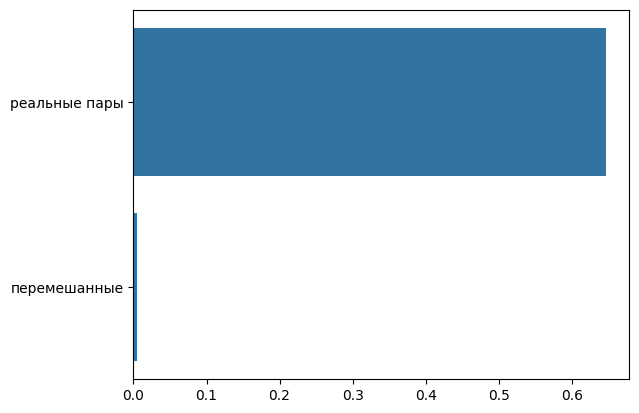

In [7]:
#gemini {
def kl(tab):
    P = tab.values / tab.values.sum()      # реальное распределение пар (тема родителя, тема ответа)
    p = (P.sum(0) + P.sum(1)) / 2          # общие доли тем
    Q = np.outer(p, p)                     # темы бросаются независимо
    m = P > 0
    return (P[m] * np.log2(P[m] / Q[m])).sum()

I1 = kl(tab)
I1_shuf = kl(pd.crosstab(e["parent"], np.random.permutation(e["mega"].values)))
print("KL от независимости =", round(I1, 3), "| перемешанное =", round(I1_shuf, 3))
sns.barplot(x=[I1, I1_shuf], y=["реальные пары", "перемешанные"])

#}

In [8]:
#на перемешанных нуль (очев), а на реальных 0.6 бит в среднем
#то есть связи очень сильные и нельзя аппроксимировать процесс последовательными случайными бросками и тд
#(значит есть граматика ура!)

In [9]:
np.log(8)

np.float64(2.0794415416798357)

In [10]:
# то есть рукомахательно родитель определяет 0.6 / 2 примерно информации - примерно четверть

## есть ли динамика грамматики?

Можно посмотреть эту же величину по годам (есть ли эволюция силы связи во времени и тд)

+gemini мне сказал что есть заумные причины что нужно брать одинаковое количество сообщений чтоб считать KL дивергенцию по годам чтоб они были сравнимы (можно принять на веру этот факт)


In [ ]:
#gemini {
years = [2023, 2024, 2025]
lenn = min((e["year"] == y).sum() for y in years)   # поровну пар из каждого года, чтоб годы были сравнимы
rows = []
for y in years:
    ey = e[e.year == y]
    for _ in range(30):                             # 30 случайных подвыборок на год
        s = ey.sample(lenn)
        real = pd.crosstab(s["parent"], s["mega"])
        perm = pd.crosstab(s["parent"], np.random.permutation(s["mega"].values))  # случайный процесс (связь разорвана)
        rows.append({"год": y, "KL": kl(real), "что": "реальное"})
        rows.append({"год": y, "KL": kl(perm), "что": "перемешанное"})
rows = pd.DataFrame(rows)
#}

In [71]:
rows

,год,KL,что
0,2023,0.531936,реальное
1,2023,0.010396,перемешанное
2,2023,0.529827,реальное
3,2023,0.009907,перемешанное
4,2023,0.530093,реальное
...,...,...,...
175,2025,0.004293,перемешанное
176,2025,0.599915,реальное
177,2025,0.004986,перемешанное
178,2025,0.599915,реальное


<Axes: xlabel='год', ylabel='KL'>

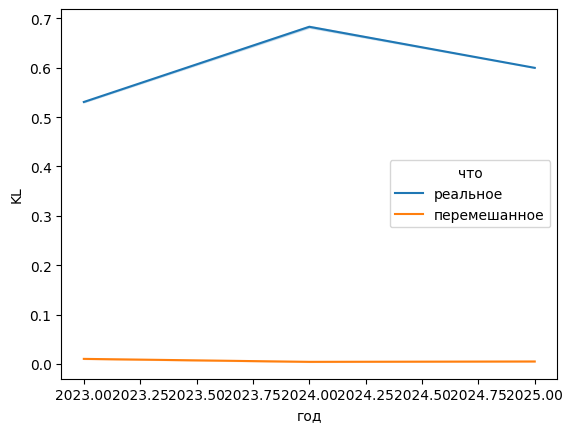

In [73]:
sns.lineplot(data=rows, x="год", y="KL", hue="что")

<Axes: xlabel='год', ylabel='KL'>

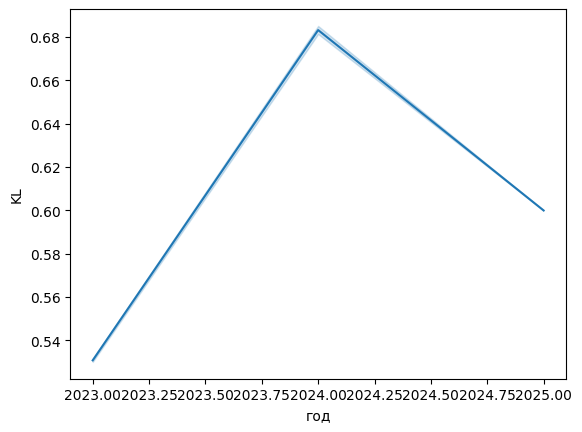

In [75]:
sns.lineplot(data=rows[rows["что"] == "реальное"], x="год", y="KL")

То есть типа граматика ссильно меняется - растет информация это типа растет количество возможных комбинаций и посдеовательностей и тд

а падает это типа становятся набор тем более примитивным?

In [76]:
#можно еще посмотреть по более коротким периодам

In [ ]:
#gemini {
e["полугодие"] = e.ts.dt.year.astype(str) + "-" + np.where(e.ts.dt.month <= 6, "H1", "H2")
wins = [w for w in sorted(e["полугодие"].unique()) if (e["полугодие"] == w).sum() >= 1500]  # окна где хватает пар
lenn = min((e["полугодие"] == w).sum() for w in wins)   # поровну из каждого окна

rows = []
for w in wins:
    ew = e[e["полугодие"] == w]
    for _ in range(30):                                 # 30 подвыборок на окно
        s = ew.sample(lenn)
        real = pd.crosstab(s["parent"], s["mega"])
        perm = pd.crosstab(s["parent"], np.random.permutation(s["mega"].values))  # случайный процесс
        rows.append({"окно": w, "KL": kl(real), "что": "реальное"})
        rows.append({"окно": w, "KL": kl(perm), "что": "перемешанное"})
rows = pd.DataFrame(rows)
#}


In [80]:
rows

,окно,KL,что
0,2023-H1,0.525051,реальное
1,2023-H1,0.025284,перемешанное
2,2023-H1,0.527818,реальное
3,2023-H1,0.021193,перемешанное
4,2023-H1,0.524916,реальное
...,...,...,...
415,2026-H1,0.020981,перемешанное
416,2026-H1,0.692664,реальное
417,2026-H1,0.014840,перемешанное
418,2026-H1,0.691079,реальное


<Axes: xlabel='окно', ylabel='KL'>

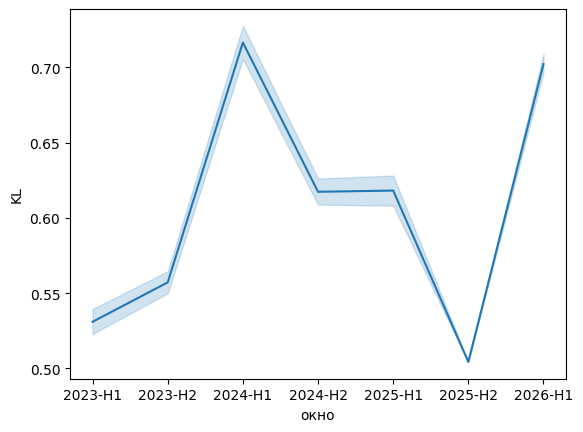

In [81]:
sns.lineplot(data=rows[rows["что"] == "реальное"], x="окно", y="KL")

In [82]:
#занимательно


Можно подумать как изменилась матрица переходов и дельту посчиатать

In [ ]:
cats

['others',
 'Баллы и апелляции',
 'Логистика и быт',
 'Мета',
 'Оффтоп/болтовня',
 'Поступление и подготовка',
 'Разбор задач']

In [31]:
pd.*?

pd.ArrowDtype
pd.BooleanDtype
pd.Categorical
pd.CategoricalDtype
pd.CategoricalIndex
pd.DataFrame
pd.DateOffset
pd.DatetimeIndex
pd.DatetimeTZDtype
pd.ExcelFile
pd.ExcelWriter
pd.Flags
pd.Float32Dtype
pd.Float64Dtype
pd.Grouper
pd.HDFStore
pd.Index
pd.IndexSlice
pd.Int16Dtype
pd.Int32Dtype
pd.Int64Dtype
pd.Int8Dtype
pd.Interval
pd.IntervalDtype
pd.IntervalIndex
pd.MultiIndex
pd.NA
pd.NaT
pd.NamedAgg
pd.Period
pd.PeriodDtype
pd.PeriodIndex
pd.RangeIndex
pd.Series
pd.SparseDtype
pd.StringDtype
pd.Timedelta
pd.TimedeltaIndex
pd.Timestamp
pd.UInt16Dtype
pd.UInt32Dtype
pd.UInt64Dtype
pd.UInt8Dtype
pd.__all__
pd.__builtins__
pd.__cached__
pd.__class__
pd.__delattr__
pd.__dict__
pd.__dir__
pd.__doc__
pd.__docformat__
pd.__eq__
pd.__file__
pd.__format__
pd.__ge__
pd.__getattribute__
pd.__git_version__
pd.__gt__
pd.__hash__
pd.__init__
pd.__init_subclass__
pd.__le__
pd.__loader__
pd.__lt__
pd.__name__
pd.__ne__
pd.__new__
pd.__package__
pd.__path__
pd.__reduce__
pd.__reduce_ex__
pd.__repr__
pd.

<Axes: xlabel='mega', ylabel='parent'>

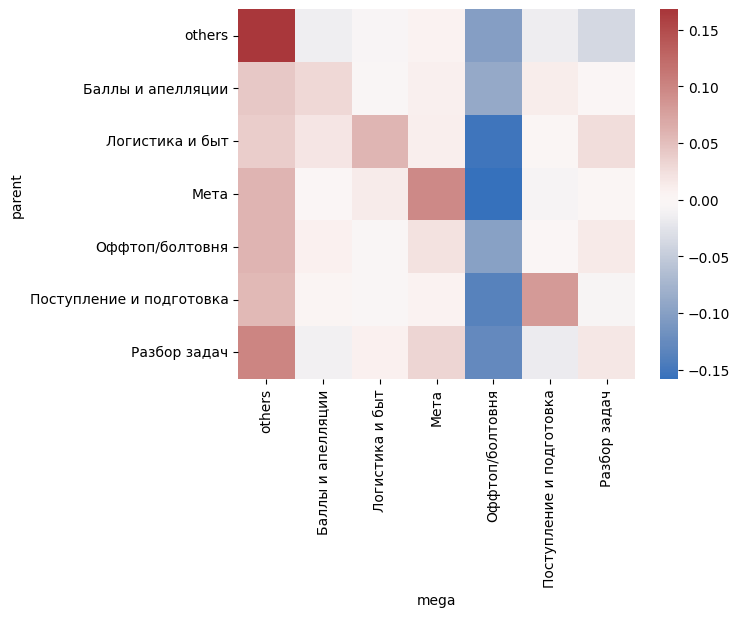

In [35]:
def matr(y):
    ey = e[e["year"] == y]
    return pd.crosstab(ey["parent"], ey["mega"], normalize="index")


delta = matr(2024) - matr(2023)
sns.heatmap(delta, center=0, cmap="vlag")

### тут видно что упал переход в болтовню с 2023 на 2024 - люди стали меньше уходить в эту историю (мб этим и объясняется "усложнение" грамматики переходов тем)

<Axes: xlabel='mega', ylabel='parent'>

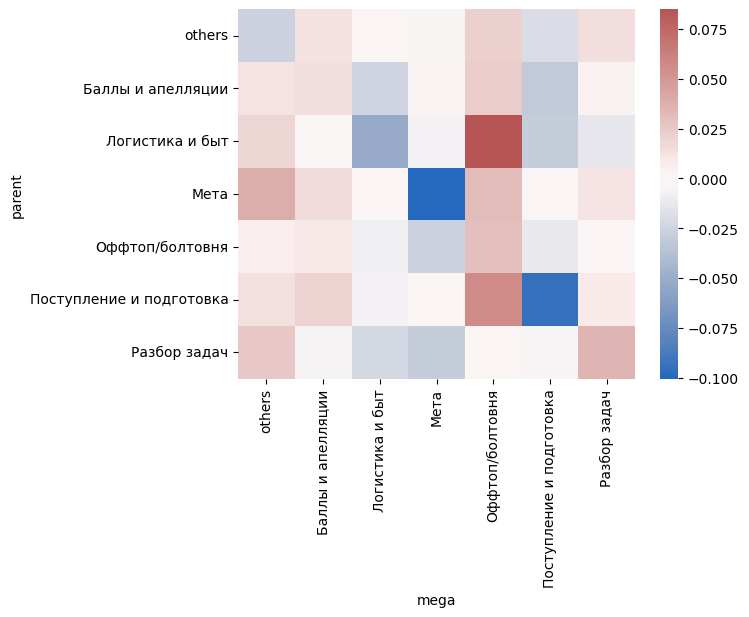

In [36]:
delta = matr(2025) - matr(2024)
sns.heatmap(delta, center=0, cmap="vlag")

### тут сильно упали переходы из некоторых тем в сами себя а также вырос переход из логистики в болтовню??? (2024-2025)

## Направление динамики во времени

типа если есть поток p из i->j, то тогда если все симметрично то есть поток из j->i точно такой же - равновесие потоков на графе, типа нет круговых течений сильных и тд (ну мы уже видели что есть неравновесие только с переходом в болтовню но не понятно про остальные)

In [40]:
tab.values

array([[ 8310,   606,   293,   349,  1897,   711,  1294],
       [  627,  4626,   332,   237,  1028,   505,   333],
       [  314,   364,  2361,   330,  1734,   397,   241],
       [  446,   229,   319,  2039,  1640,   233,   273],
       [ 1444,   707,  1061,  1135, 13884,   970,   755],
       [  787,   511,   341,   208,  1596,  4881,   249],
       [  933,   246,   162,   213,   865,   180,  1751]])

In [41]:

F = tab.values / tab.values.sum() #в долях

to, fr = [], []
for i in range(K):
    for j in range(K):
        if i < j:
            to.append(F[i, j])
            fr.append(F[j, i])


<Axes: >

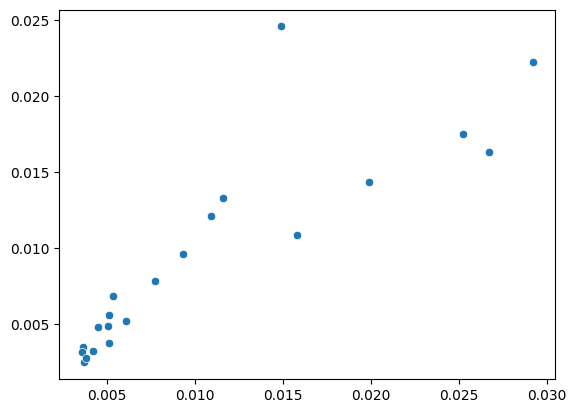

In [42]:
sns.scatterplot(x=to, y=fr)

In [44]:
#в идеале должна быть прямая
#непонятно насколько данное расхождение критичное но все выглядит как будто адекватно близко к симметрии

Давайте сделаем опять наш любимый перестановочный тест 

берем мультисет детей, родителей и рандомно будем делать пары кто с кем (доли каждой темы сохраняем), и считаем распределение ассиметрии (по факту мера фробениуса между матрицей переходов и транспонированной)

In [54]:
def asym(M):
    M = M / M.sum()
    return ((M - M.T) ** 2).sum() 

real = asym(tab.values)

naive = []
for p in range(300):
    shuffled = np.random.permutation(e["mega"].values)
    t = pd.crosstab(e["parent"], shuffled)
    naive.append(asym(t.values))

print("реальных", round(real, 3), "| перемешанных", round(np.mean(naive), 3))

реальных 0.001 | перемешанных 0.001


In [ ]:
#слишком маленькие числа, тк квадраты все убивают
#давайте не меру фробениуса а просто сумму модулей

In [55]:
def asym(M):
    M = M / M.sum()
    return np.abs(M - M.T).sum() 

real = asym(tab.values)

naive = []
for p in range(300):
    shuffled = np.random.permutation(e["mega"].values)
    t = pd.crosstab(e["parent"], shuffled)
    naive.append(asym(t.values))

print("реальных", round(real, 3), "| перемешанных", round(np.mean(naive), 3))

реальных 0.114 | перемешанных 0.119


In [ ]:
#тут перемешанные оказались больше реальных - это нетривиально

#мб слишком рандомно делали перемешанные - типа рандом пары слишком сильно, надо просто рандомно перенаправлять ребра
#тогда сильные числа на диагонали сохранятся у перемешанных
#+это все сделать и посмотреть распределение по сумме модулей 

real 0.114 | permute 0.018


<Axes: ylabel='Count'>

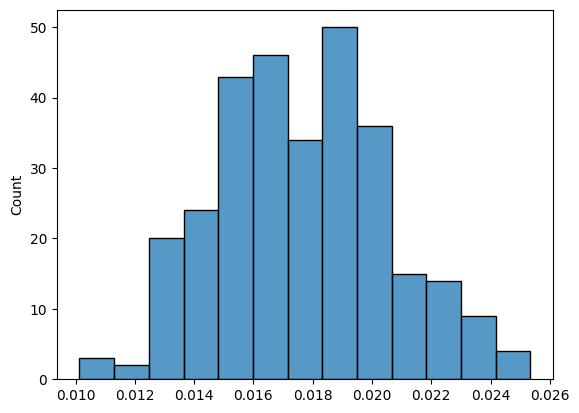

In [60]:
#vibe code {
src = e["parent"].map({c: i for i, c in enumerate(cats)}).to_numpy()
dst = e["mega"].map({c: i for i, c in enumerate(cats)}).to_numpy()
def table(s, d):
    T = np.zeros((K, K)); np.add.at(T, (s, d), 1); return T

flip = []
for _ in range(300):
    coin = np.random.random(len(src)) < 0.5
    s2 = np.where(coin, dst, src)
    d2 = np.where(coin, src, dst)
    M = table(s2, d2)
    flip.append(asym(M / M.sum()))

print("real", round(real, 3), "| permute", round(np.mean(flip), 3))
sns.histplot(flip)
#}


In [61]:
#тут видно что если потоки в обе стороны равновесны, то статистика ассиметрии на порядок меньше чем реальная

#тогда очев сильно несиметрично все!

Посмотрим топ по перевесу по ребрам

<Axes: >

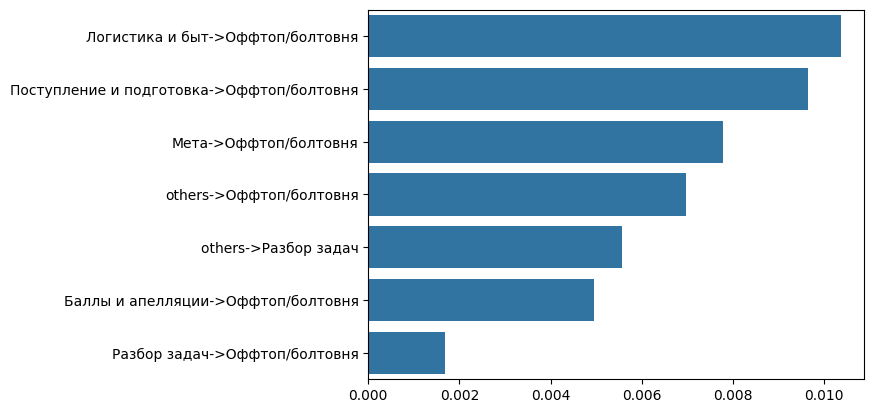

In [51]:
x = F - F.T # как раз разность потоков
pairs = []
for i in range(K):
    for j in range(K):
        if J[i, j] > 0:
            pairs.append((x[i, j], cats[i] + "->" + cats[j]))
pairs.sort(reverse=True)

vals = [v for v, _ in pairs[:7]]
names = [n for _, n in pairs[:7]]
sns.barplot(x=vals, y=names)

In [48]:
#содержательные темы (логистика, поступление, разбор) утекают в оффтоп. 
# на тему чаще отвечают шуткой чем наоборот
# а еще есть промежуточный поток others -> разбор задач -> оффтоп

#### То есть если переформулировать эту историю в терминах потоков (вероятности) на графах то у нас циклов не видно, у нас неравновесие сильное! и у нас есть сильный сток в одной вершине (оффтоп)!!!

## мини итоги

1. у чата есть сильная грамматика: знание темы родителя четверть(очень примерно) информации ребенка
2. частоты стоят, сила связей двигается по годам!!
3. нет круговых течений тем, но есть стоковое в offtop
